In [ ]:
import shapefile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import tree
from IPython.display import Image
import pydotplus
import graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

## Data Cleaning

In [ ]:
incidents= pd.read_csv('NYPD_Use_of_Force_Incidents_20260424.csv')
subjects= pd.read_csv('NYPD_Use_of_Force__Subjects_20260424.csv')
service_members= pd.read_csv('NYPD_Use_of_Force__Members_of_Service_20260424.csv')
cols=incidents.columns.tolist() + subjects.drop(['TRI Incident Number'], axis=1).columns.tolist() + ['M1 ForceType', 'M1 InjuryLevel', 'M1 Member Injured',
       'M1 Rank Grouped', 'M1 Assignment', 'M1 Member Gender', 'M1 Race', 'M2 ForceType', 'M2 InjuryLevel', 'M2 Member Injured',
       'M2 Rank Grouped', 'M2 Assignment', 'M2 Member Gender', 'M2 Race']
merged_UOF=pd.DataFrame(columns=cols)
for tri in incidents['TRI Incident Number']:
    if len(service_members[service_members['TRI Incident Number']==tri]) <= 2 and len(subjects[subjects['TRI Incident Number']==tri]) == 1:
        tempdf = pd.DataFrame(columns=cols)
        if len(service_members[service_members['TRI Incident Number']==tri])==1:
            for col in incidents.columns:
                tempdf.loc[0, col] = incidents[incidents['TRI Incident Number']==tri][col].values[0]
            for col in subjects.drop(['TRI Incident Number'], axis=1).columns:
                tempdf.loc[0, col] = subjects[subjects['TRI Incident Number']==tri][col].values[0]
            tempdf.loc[0, 'M1 ForceType'] = service_members[service_members['TRI Incident Number']==tri]['ForceType'].values[0]
            tempdf.loc[0, 'M1 InjuryLevel'] = service_members[service_members['TRI Incident Number']==tri]['InjuryLevel'].values[0]
            tempdf.loc[0, 'M1 Member Injured'] = service_members[service_members['TRI Incident Number']==tri]['Member Injured'].values[0]
            tempdf.loc[0, 'M1 Rank Grouped'] = service_members[service_members['TRI Incident Number']==tri]['Rank Grouped'].values[0]
            tempdf.loc[0, 'M1 Assignment'] = service_members[service_members['TRI Incident Number']==tri]['Assignment'].values[0]
            tempdf.loc[0, 'M1 Member Gender'] = service_members[service_members['TRI Incident Number']==tri]['Member Gender'].values[0]
            tempdf.loc[0, 'M1 Race'] = service_members[service_members['TRI Incident Number']==tri]['Race'].values[0]
            tempdf.loc[0, 'M2 ForceType'] = np.nan
            tempdf.loc[0, 'M2 InjuryLevel'] = np.nan
            tempdf.loc[0, 'M2 Member Injured'] = np.nan
            tempdf.loc[0, 'M2 Rank Grouped'] = np.nan
            tempdf.loc[0, 'M2 Assignment'] = np.nan
            tempdf.loc[0, 'M2 Member Gender'] = np.nan
            tempdf.loc[0, 'M2 Race'] = np.nan
        elif len(service_members[service_members['TRI Incident Number']==tri])==2:
            for col in incidents.columns:
                tempdf.loc[0, col] = incidents[incidents['TRI Incident Number']==tri][col].values[0]
            for col in subjects.drop(['TRI Incident Number'], axis=1).columns:
                tempdf.loc[0, col] = subjects[subjects['TRI Incident Number']==tri][col].values[0]
            tempdf.loc[0, 'M1 ForceType'] = service_members[service_members['TRI Incident Number']==tri].iloc[0]['ForceType']
            tempdf.loc[0, 'M1 InjuryLevel'] = service_members[service_members['TRI Incident Number']==tri].iloc[0]['InjuryLevel']
            tempdf.loc[0, 'M1 Member Injured'] = service_members[service_members['TRI Incident Number']==tri].iloc[0]['Member Injured']
            tempdf.loc[0, 'M1 Rank Grouped'] = service_members[service_members['TRI Incident Number']==tri].iloc[0]['Rank Grouped']
            tempdf.loc[0, 'M1 Assignment'] = service_members[service_members['TRI Incident Number']==tri].iloc[0]['Assignment']
            tempdf.loc[0, 'M1 Member Gender'] = service_members[service_members['TRI Incident Number']==tri].iloc[0]['Member Gender']
            tempdf.loc[0, 'M1 Race'] = service_members[service_members['TRI Incident Number']==tri].iloc[0]['Race']
            tempdf.loc[0, 'M2 ForceType'] = service_members[service_members['TRI Incident Number']==tri].iloc[1]['ForceType']
            tempdf.loc[0, 'M2 InjuryLevel'] = service_members[service_members['TRI Incident Number']==tri].iloc[1]['InjuryLevel']
            tempdf.loc[0, 'M2 Member Injured'] = service_members[service_members['TRI Incident Number']==tri].iloc[1]['Member Injured']
            tempdf.loc[0, 'M2 Rank Grouped'] = service_members[service_members['TRI Incident Number']==tri].iloc[1]['Rank Grouped']
            tempdf.loc[0, 'M2 Assignment'] = service_members[service_members['TRI Incident Number']==tri].iloc[1]['Assignment']
            tempdf.loc[0, 'M2 Member Gender'] = service_members[service_members['TRI Incident Number']==tri].iloc[1]['Member Gender']
            tempdf.loc[0, 'M2 Race'] = service_members[service_members['TRI Incident Number']==tri].iloc[1]['Race']
        #print(tempdf)
        merged_UOF = pd.concat([merged_UOF, tempdf], ignore_index=True)
merged_UOF.head()
merged_UOF.to_csv('Single_Subject_TRI.csv', index=False)

## Decision Tree Classification

In [ ]:
Single_Subject_UOF=pd.read_csv('/content/Single_Subject_TRI.csv')
TRI_with_counts=pd.read_csv('/content/TRI with counts.csv')

In [ ]:
Single_Subject_UOF['ForceCategory']=pd.Series()
classified=0

for index, sub in Single_Subject_UOF.iterrows():

    if sub['Subject Injury Level'] in ['Death', 'Serious Physical Injury'] and sub['ForceType'] != 'Firearm':
        Single_Subject_UOF.loc[index, 'ForceCategory'] = '3'
        classified += 1
    elif sub['ForceType'] == 'Firearm':
        Single_Subject_UOF.loc[index, 'ForceCategory'] = '4'
        classified += 1
    elif sub['ForceType'] in ['Impact Weapon', 'Police Canine']:
        Single_Subject_UOF.loc[index, 'ForceCategory'] = '2'
        classified += 1
    elif sub['ForceType'] == 'Electrical Weapon' and sub['Subject Injury Level'] in ['Substantial Physical Injury']:
        Single_Subject_UOF.loc[index, 'ForceCategory'] = '2'
        classified += 1
    elif sub['ForceType'] =='Electrical Weapon' and sub['Subject Injury Level'] in ['Physical Injury','No Injury']:
        Single_Subject_UOF.loc[index, 'ForceCategory'] = '1'
        classified += 1
    elif sub['ForceType'] in ['Physical Force', 'OC Spray', 'Restraining Mesh Blanket']:
        Single_Subject_UOF.loc[index, 'ForceCategory'] = '1'
        classified += 1


In [ ]:
Single_Subject_UOF.columns

Index(['TRI Incident Number', 'ForceType', 'Occurrence Date', 'Incident Pct',
       'Patrol Borough', 'YearMonthShort', 'BasisForEncounter',
       'Subject Injury Level', 'Subject Injured', 'Age', 'Subject Race',
       'Subject Gender', 'Force Against MOS', 'Subject Used Force',
       'M1 ForceType', 'M1 InjuryLevel', 'M1 Member Injured',
       'M1 Rank Grouped', 'M1 Assignment', 'M1 Member Gender', 'M1 Race',
       'M2 ForceType', 'M2 InjuryLevel', 'M2 Member Injured',
       'M2 Rank Grouped', 'M2 Assignment', 'M2 Member Gender', 'M2 Race',
       'ForceCategory'],
      dtype='object')

In [ ]:
TRI_with_counts.columns

Index(['TRI Incident Number', 'ForceType', 'Occurrence Date', 'Incident Pct',
       'Patrol Borough', 'YearMonthShort', 'BasisForEncounter', 'MOS count',
       'MOS highest rank', 'MOS injured count', 'Subject count',
       'Subject Injured count'],
      dtype='object')

In [ ]:
#plt.hist(Single_Subject_UOF['Subject Race'],align='mid')

categories = TRI_with_counts['Subject Race'].value_counts().index
counts = TRI_with_counts['Subject Race'].value_counts().values
plt.bar(categories, counts, width=0.5)
plt.title('Incidents By Race')
plt.ylabel('Incident Count')
plt.xlabel('Subject Race')
plt.show()

KeyError: 'Subject Race'

In [ ]:
# Let's take Forcecategory as the target variable.
y=Single_Subject_UOF.loc[:,"ForceCategory"]
#y=pd.get_dummies(y)

# Get the feature space.
X=Single_Subject_UOF.drop(columns=['ForceCategory', 'Subject Injury Level','Subject Injured', 'TRI Incident Number', 'ForceType', 'Occurrence Date', 'Incident Pct', 'YearMonthShort','M1 ForceType', 'M2 ForceType'])
print(X.columns.tolist())
X=pd.get_dummies(X)


['Patrol Borough', 'BasisForEncounter', 'Age', 'Subject Race', 'Subject Gender', 'Force Against MOS', 'Subject Used Force', 'M1 InjuryLevel', 'M1 Member Injured', 'M1 Rank Grouped', 'M1 Assignment', 'M1 Member Gender', 'M1 Race', 'M2 InjuryLevel', 'M2 Member Injured', 'M2 Rank Grouped', 'M2 Assignment', 'M2 Member Gender', 'M2 Race']


2 0.5358633353957418
7 0.5857434772925546
12 0.5860554262236104
17 0.578119821945763
22 0.6007833193584196
27 0.6008996653611334
32 0.6012919319824125
37 0.6274989096955728
42 0.628484934477712
47 0.6303880596354738
52 0.6277489400020775
57 0.6288274592141528
62 0.6214483521862286
67 0.6208021029331902
72 0.6129714993386342
77 0.6128425285643502
82 0.6118991998613712
87 0.5756389491768263
92 0.5765436928573994
97 0.5766923384095991


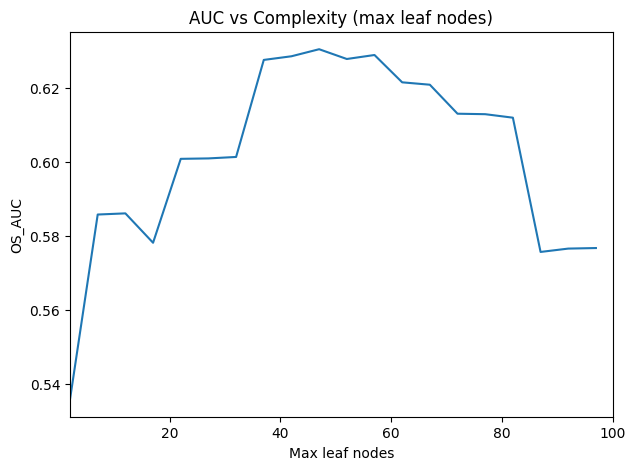

[np.float64(0.5358633353957418), np.float64(0.5857434772925546), np.float64(0.5860554262236104), np.float64(0.578119821945763), np.float64(0.6007833193584196), np.float64(0.6008996653611334), np.float64(0.6012919319824125), np.float64(0.6274989096955728), np.float64(0.628484934477712), np.float64(0.6303880596354738), np.float64(0.6277489400020775), np.float64(0.6288274592141528), np.float64(0.6214483521862286), np.float64(0.6208021029331902), np.float64(0.6129714993386342), np.float64(0.6128425285643502), np.float64(0.6118991998613712), np.float64(0.5756389491768263), np.float64(0.5765436928573994), np.float64(0.5766923384095991)]


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.5,random_state=999)
AUC_OS=[]
for i in range(2,100,5):
    dt=DecisionTreeClassifier(max_leaf_nodes=i,random_state=999)
    dt.fit(X_train,y_train)
    pred=dt.predict_proba(X_test) # predicted probability of y = 1
    AUC_OS.append(roc_auc_score(y_test, pred, multi_class='ovr'))
    print(i,roc_auc_score(y_test, pred, multi_class='ovr'))
plt.figure(figsize=(7,5))
plt.plot(range(2,100,5),AUC_OS)
plt.xlabel("Max leaf nodes")
plt.ylabel("OS_AUC")
plt.title("AUC vs Complexity (max leaf nodes)")
plt.xlim(2,100)
plt.show()
print(AUC_OS)

['Patrol Borough', 'BasisForEncounter', 'Age', 'Subject Race', 'Subject Gender', 'Force Against MOS', 'Subject Used Force', 'M1 InjuryLevel', 'M1 Member Injured', 'M1 Rank Grouped', 'M1 Assignment', 'M1 Member Gender', 'M1 Race', 'M2 InjuryLevel', 'M2 Member Injured', 'M2 Rank Grouped', 'M2 Assignment', 'M2 Member Gender', 'M2 Race']
2 0.5358633353957418
7 0.5857434772925546
12 0.5860554262236104
17 0.578119821945763
22 0.6007833193584196
27 0.6008996653611334
32 0.6012919319824125
37 0.6274989096955728
42 0.628484934477712


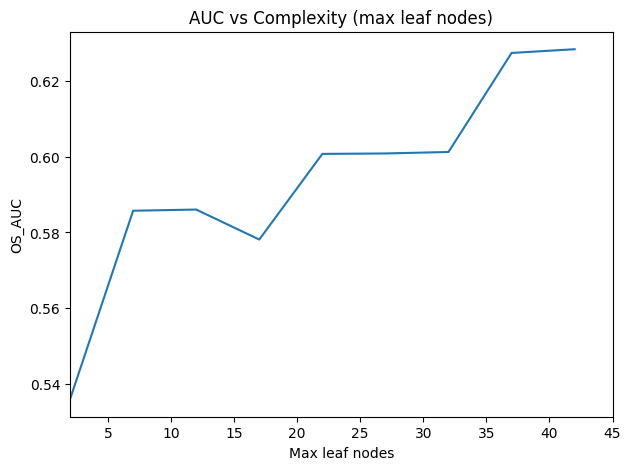

[np.float64(0.5358633353957418), np.float64(0.5857434772925546), np.float64(0.5860554262236104), np.float64(0.578119821945763), np.float64(0.6007833193584196), np.float64(0.6008996653611334), np.float64(0.6012919319824125), np.float64(0.6274989096955728), np.float64(0.628484934477712)]


In [ ]:
plt# Let's take subject injury level as the target variable.
y=Single_Subject_UOF["ForceCategory"]

# Get the feature space.
X=Single_Subject_UOF.drop(columns=['ForceCategory', 'Subject Injury Level','Subject Injured', 'TRI Incident Number', 'ForceType', 'Occurrence Date', 'Incident Pct', 'YearMonthShort','M1 ForceType', 'M2 ForceType'])
print(X.columns.tolist())
X=pd.get_dummies(X)
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.5,random_state=999)
AUC_OS=[]
for i in range(2,45,5):
    dt=DecisionTreeClassifier(max_leaf_nodes=i,random_state=999)
    dt.fit(X_train,y_train)
    pred=dt.predict_proba(X_test) # predicted probability of y = 1
    AUC_OS.append(roc_auc_score(y_test, pred, multi_class='ovr'))
    print(i,roc_auc_score(y_test, pred, multi_class='ovr'))
plt.figure(figsize=(7,5))
plt.plot(range(2,45,5),AUC_OS)
plt.xlabel("Max leaf nodes")
plt.ylabel("OS_AUC")
plt.title("AUC vs Complexity (max leaf nodes)")
plt.xlim(2,45)
plt.show()
print(AUC_OS)

In [ ]:
pred=dt.predict_proba(X_test) # predicted probability of y = 1
print('Out of Sample AUC score:',roc_auc_score(y_test, pred, multi_class='ovr'))
Feature_importance=pd.DataFrame([list(X_train.columns),list(dt.feature_importances_)]).T
Feature_importance.columns=["variables","importance"]

# list the top 5 most important features in order
print(Feature_importance.sort_values(by="importance",ascending=False).iloc[:5,:])

Out of Sample AUC score: 0.628484934477712
                             variables importance
39           Force Against MOS_Firearm   0.345859
0                                  Age   0.088478
38  Force Against MOS_Displayed Weapon   0.035695
5                  Patrol Borough_PBMS   0.033785
74                    M1 Race_HISPANIC   0.032056


In [ ]:
Single_Subject_UOF['Subject Injury Level'].value_counts()

,count
Subject Injury Level,
No Injury,22747
Physical Injury,10974
Substantial Physical Injury,305
Serious Physical Injury,299
Death,44


In [ ]:
print(len(Single_Subject_UOF[Single_Subject_UOF['Subject Injury Level'] =='Substantial Physical Injury'])/len(Single_Subject_UOF['Age']))

0.008874276237306876


(array([34., 68., 70., 51., 30., 21., 16.,  7.,  1.,  1.]),
 array([13. , 19.8, 26.6, 33.4, 40.2, 47. , 53.8, 60.6, 67.4, 74.2, 81. ]),
 <BarContainer object of 10 artists>)

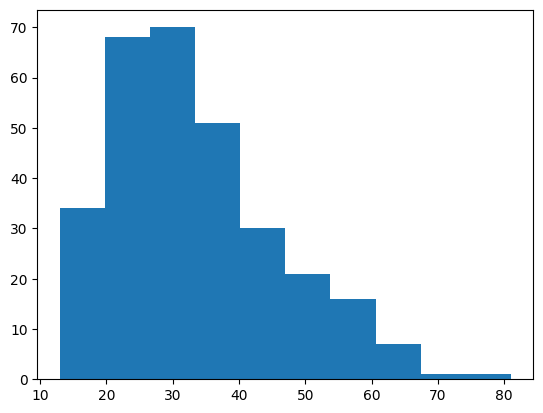

In [ ]:
plt.hist(Single_Subject_UOF[Single_Subject_UOF['Subject Injury Level'] =='Substantial Physical Injury']['Age'])

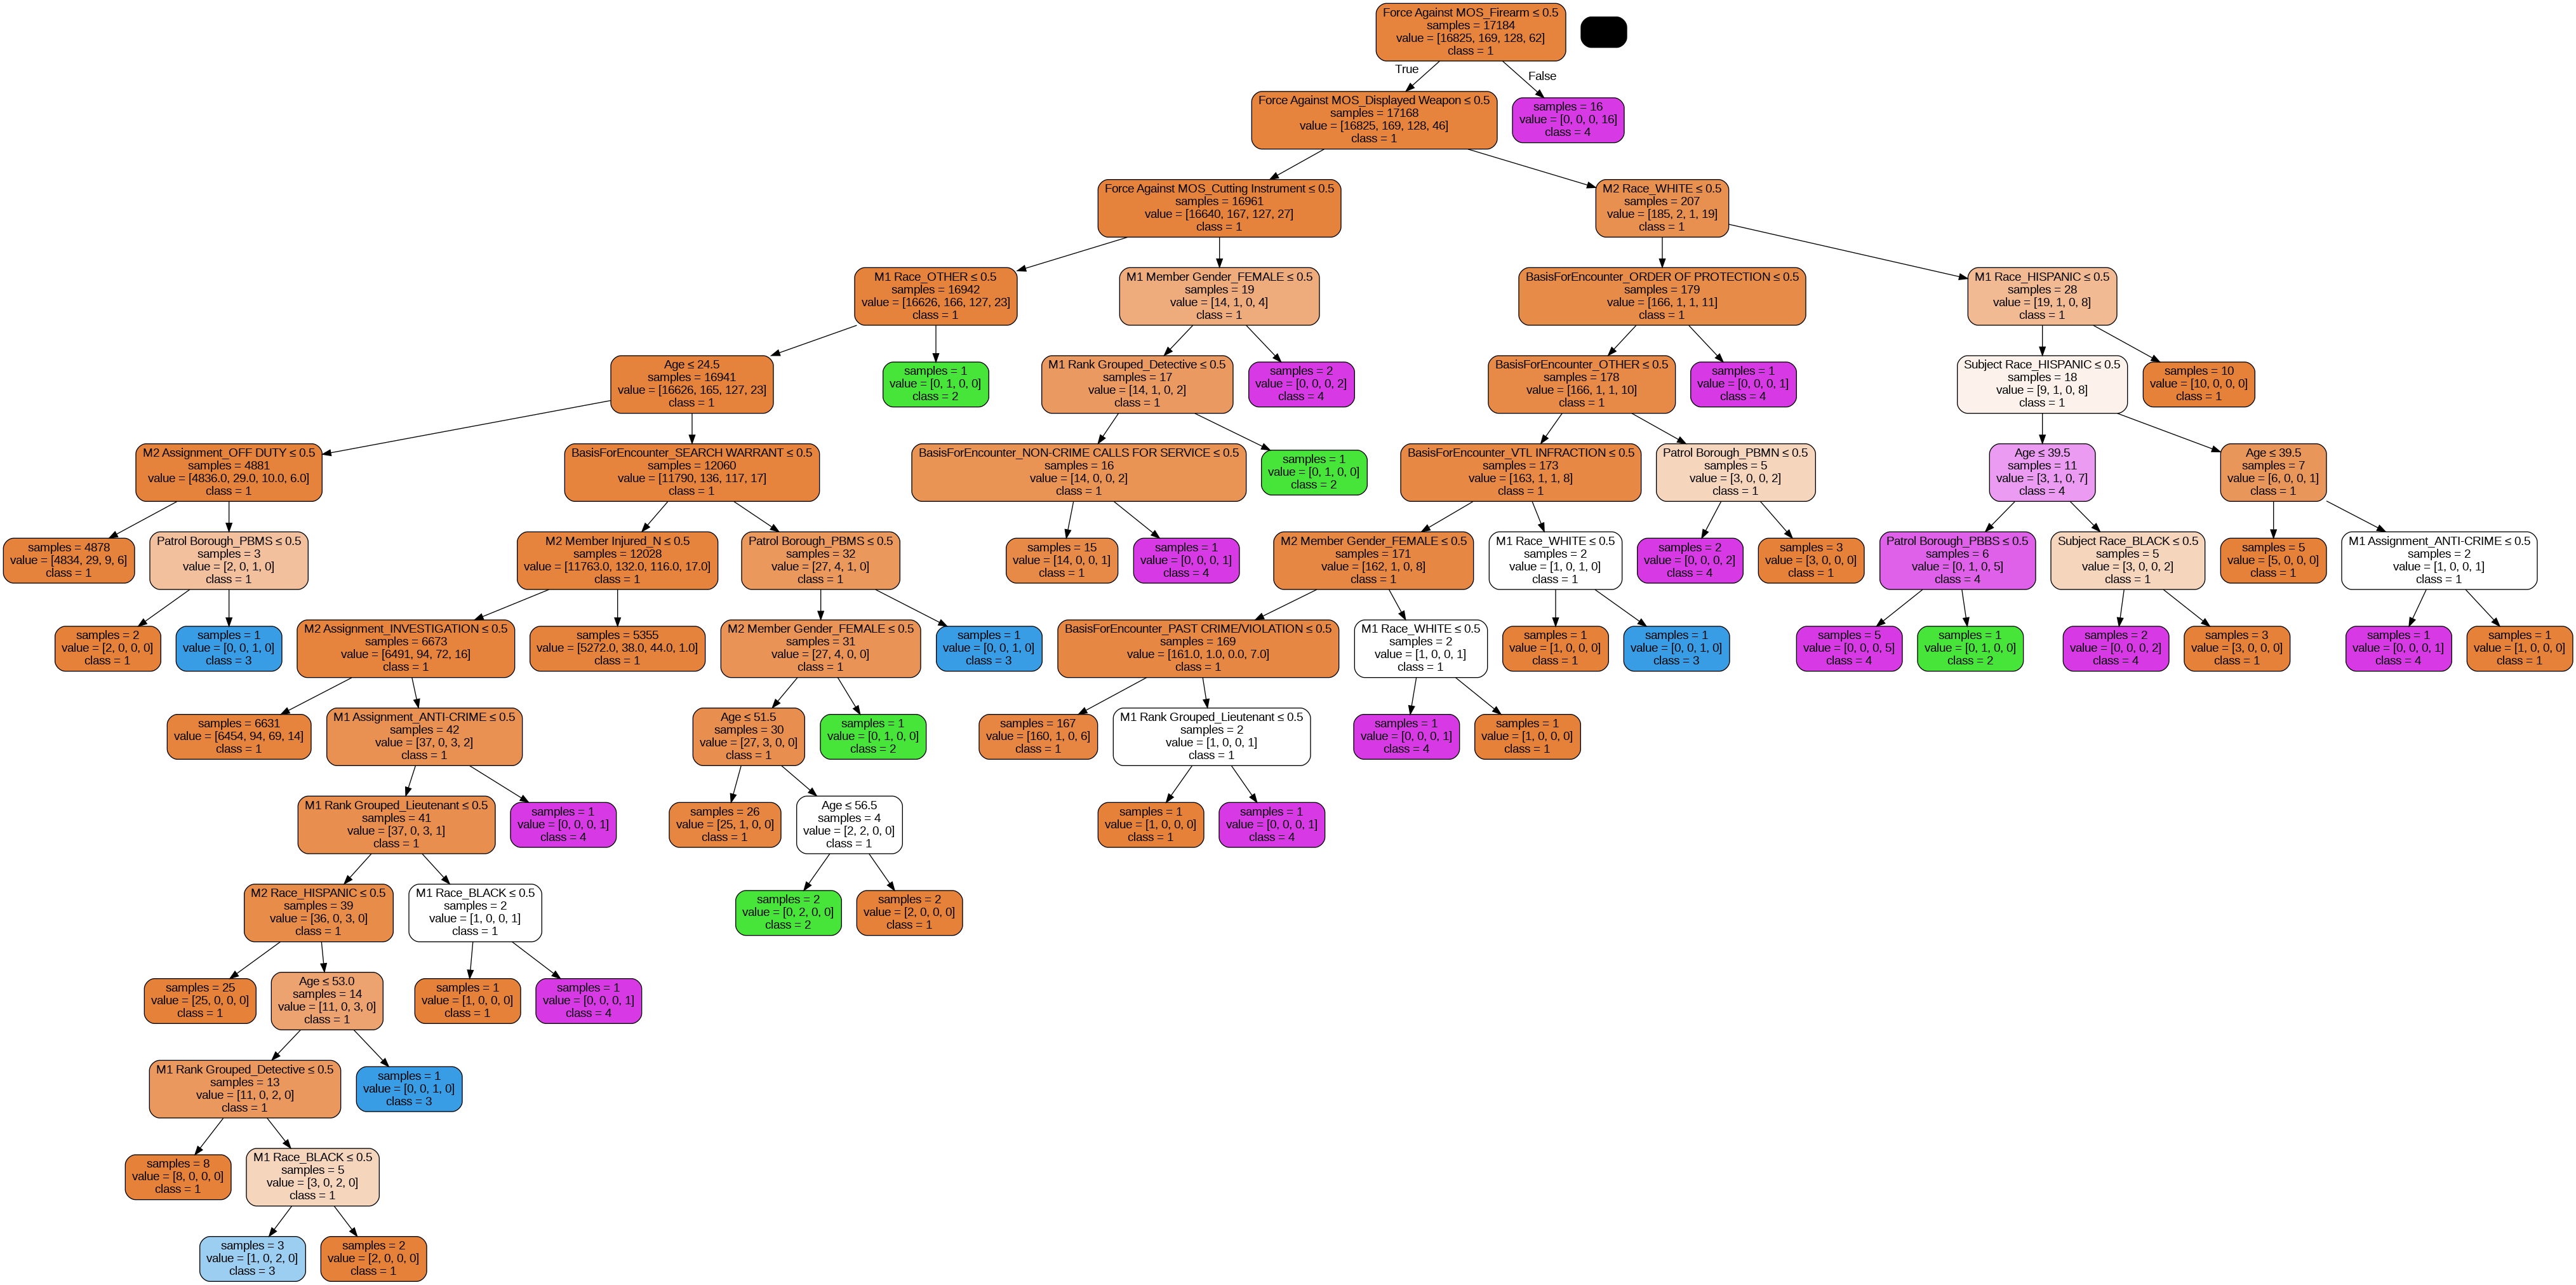

In [ ]:
thestring = tree.export_graphviz(dt, out_file=None,
                         feature_names=X_train.columns.tolist(),
                         class_names=['1','2','3','4'],
                         filled=True, rounded=True,
                         special_characters=True,impurity=False,)
graph = pydotplus.graph_from_dot_data(thestring)
Image(graph.create_png())

## Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Let's take subject injury level as the target variable.
y=Single_Subject_UOF["ForceCategory"]

# Get the feature space.
X=Single_Subject_UOF.drop(columns=['ForceCategory', 'Subject Injury Level','Subject Injured', 'TRI Incident Number', 'ForceType', 'Occurrence Date', 'Incident Pct', 'YearMonthShort','M1 ForceType', 'M2 ForceType'])
print(X.columns.tolist())
X=pd.get_dummies(X)

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.5,random_state=999)
param_grid = {'n_estimators':range(1,51,5),'max_leaf_nodes':range(2,20,2)}
rf = RandomForestClassifier(n_jobs=-1,)
gs = GridSearchCV(rf,param_grid=param_grid,scoring='accuracy')
rs = gs.fit(X_train,y_train)
pred=rs.predict_proba(X_test)
print(rs.best_estimator_)


['Patrol Borough', 'BasisForEncounter', 'Age', 'Subject Race', 'Subject Gender', 'Force Against MOS', 'Subject Used Force', 'M1 InjuryLevel', 'M1 Member Injured', 'M1 Rank Grouped', 'M1 Assignment', 'M1 Member Gender', 'M1 Race', 'M2 InjuryLevel', 'M2 Member Injured', 'M2 Rank Grouped', 'M2 Assignment', 'M2 Member Gender', 'M2 Race']
RandomForestClassifier(max_leaf_nodes=18, n_estimators=6, n_jobs=-1)


In [ ]:
pred=rs.predict_proba(X_test)
print('Random forest accuracy:',roc_auc_score(y_test,pred,multi_class='ovr'))

Random forest accuracy: 0.6762119515002265


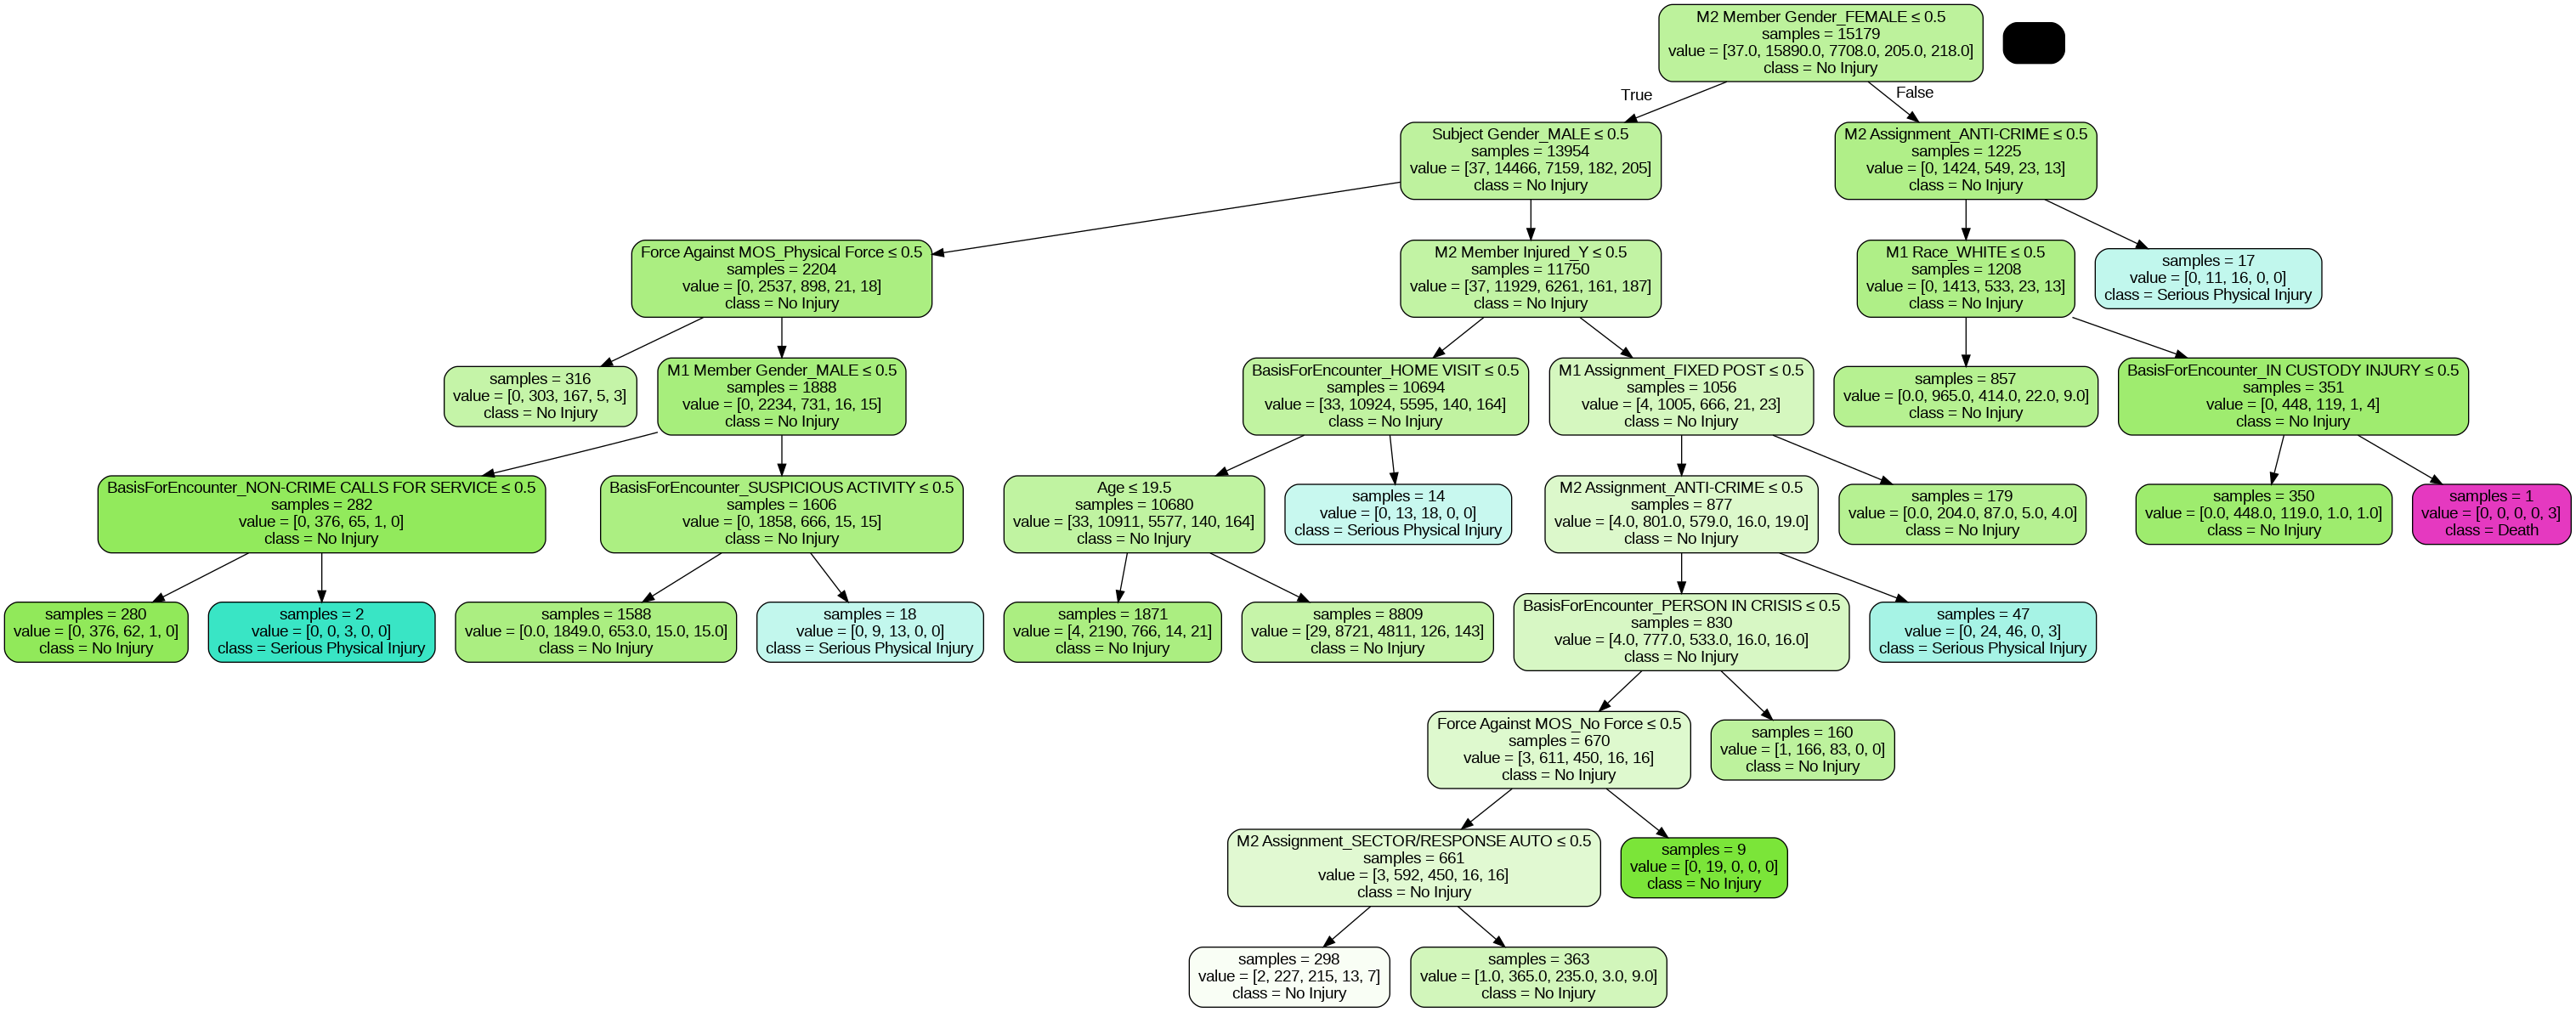

In [ ]:
thestring = tree.export_graphviz(rs.best_estimator_[0], out_file=None,
                         feature_names=X_train.columns.tolist(),
                         class_names=y_train.unique().tolist(),
                         filled=True, rounded=True,
                         special_characters=True,impurity=False,)
graph = pydotplus.graph_from_dot_data(thestring)
Image(graph.create_png())

In [ ]:
# Let's take subject injury level as the target variable.
y=Single_Subject_UOF["ForceCategory"]

# Get the feature space.
X=Single_Subject_UOF.drop(columns=['ForceCategory', 'Subject Injury Level','Subject Injured', 'TRI Incident Number', 'ForceType', 'Occurrence Date', 'Incident Pct', 'YearMonthShort','M1 ForceType', 'M2 ForceType'])
print(X.columns.tolist())
X=pd.get_dummies(X)

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.5,random_state=999)
rf = RandomForestClassifier(max_leaf_nodes=18, n_estimators=6, n_jobs=-1)
rf.fit(X_train,y_train)
pred=rf.predict_proba(X_test)
#pred=rs.predict_proba(X_test)
print('Random forest accuracy:',roc_auc_score(y_test,pred,multi_class='ovr'))
Feature_importance=pd.DataFrame([list(X_train.columns),list(r.feature_importances_)]).T
Feature_importance.columns=["variables","importance"]
print(Feature_importance.sort_values(by="importance",ascending=False).iloc[:5,:])
#print(rf.best_estimator_)

['Patrol Borough', 'BasisForEncounter', 'Age', 'Subject Race', 'Subject Gender', 'Force Against MOS', 'Subject Used Force', 'M1 InjuryLevel', 'M1 Member Injured', 'M1 Rank Grouped', 'M1 Assignment', 'M1 Member Gender', 'M1 Race', 'M2 InjuryLevel', 'M2 Member Injured', 'M2 Rank Grouped', 'M2 Assignment', 'M2 Member Gender', 'M2 Race']
Random forest accuracy: 0.6186339934343523
                     variables importance
39   Force Against MOS_Firearm   0.547005
0                          Age   0.116556
44        Subject Used Force_Y   0.073492
72               M1 Race_ASIAN     0.0645
107              M2 Race_WHITE   0.043729


In [ ]:
estimatornum=1
for r in rs.best_estimator_:
  Feature_importance=pd.DataFrame([list(X_train.columns),list(r.feature_importances_)]).T
  Feature_importance.columns=["variables","importance"]

# list the top 5 most important features in order
  print('estimator',estimatornum,'feature importance')
  estimatornum+=1
  print(Feature_importance.sort_values(by="importance",ascending=False).iloc[:5,:])

estimator 1 feature importance
                               variables importance
39             Force Against MOS_Firearm   0.571061
37  Force Against MOS_Cutting Instrument   0.074504
45              M1 InjuryLevel_No Injury   0.054195
44                  Subject Used Force_Y    0.04389
78        M2 InjuryLevel_Physical Injury    0.04092
estimator 2 feature importance
                             variables importance
39           Force Against MOS_Firearm   0.528881
0                                  Age   0.091053
26    BasisForEncounter_VTL INFRACTION   0.059305
38  Force Against MOS_Displayed Weapon   0.051654
19             BasisForEncounter_OTHER   0.051203
estimator 3 feature importance
                              variables importance
39            Force Against MOS_Firearm   0.524968
72                        M1 Race_ASIAN   0.093546
38   Force Against MOS_Displayed Weapon   0.073935
101               M2 Member Gender_MALE   0.055744
100             M2 Member Gender_FEMALE 